---
# Cover Page

**Name:** Anotida B Gwande

**Registration Number:** R2420897

**Program Code:** HACS


# 📈 Regime Change Detection in Apple Inc. (AAPL) Daily Stock Prices
### Application: Time Series – Assignment #3
**Model:** Regime Change Detection using Hidden Markov Models (HMM) and CUSUM

**Dataset:** Apple Inc. (AAPL) Daily Closing Prices — Yahoo Finance (2018–2024)

---

In [46]:
# Install all required libraries
!pip install yfinance hmmlearn ruptures --quiet

## 📦 Import Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import ruptures as rpt

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Definition

### 1.1 Regime Change (Structural Break)

A **regime change** occurs when the statistical properties of a time series shift suddenly at some unknown point $\tau$. Formally, let $\{y_t\}_{t=1}^{T}$ be a time series. A structural break at time $\tau$ implies:

$$y_t = \begin{cases} \mu_1 + \epsilon_t, & t \leq \tau \\ \mu_2 + \epsilon_t, & t > \tau \end{cases}, \quad \epsilon_t \sim \mathcal{N}(0, \sigma^2)$$

where $\mu_1 \neq \mu_2$ (and possibly $\sigma_1^2 \neq \sigma_2^2$).

### 1.2 Hidden Markov Model (HMM)

An HMM models a sequence of observed returns $\{r_t\}$ as being generated by an unobserved (hidden) discrete state $\{S_t\} \in \{1, 2, \ldots, K\}$. The model is defined by:

- **Initial state probabilities:** $\pi_k = P(S_1 = k)$
- **Transition matrix:** $A_{ij} = P(S_t = j \mid S_{t-1} = i)$
- **Emission distribution:** $r_t \mid S_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2)$

The joint likelihood of observations and states is:

$$P(r_{1:T}, S_{1:T}) = \pi_{S_1} \prod_{t=2}^{T} A_{S_{t-1}, S_t} \prod_{t=1}^{T} \mathcal{N}(r_t; \mu_{S_t}, \sigma_{S_t}^2)$$

Parameters are estimated via the **Baum-Welch algorithm** (a special case of Expectation-Maximization).

### 1.3 CUSUM Statistic

The **Cumulative Sum (CUSUM)** statistic detects structural breaks by monitoring cumulative deviations from a reference mean $\bar{r}$:

$$C_t = \sum_{i=1}^{t} (r_i - \bar{r})$$

A significant structural break is flagged when $|C_t|$ exceeds a critical threshold $h$, typically derived from a Brownian motion boundary.

### 1.4 Daily Log Return

Returns are computed as:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

where $P_t$ is the adjusted closing price at time $t$.

In [48]:
# Download AAPL daily data from Yahoo Finance
ticker = 'AAPL'
start_date = '2018-01-01'
end_date   = '2024-12-31'

raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
print(f'Raw data shape: {raw.shape}')
print(f'Columns: {list(raw.columns)}')
raw.head()

Raw data shape: (1760, 5)
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297165,40.839984,40.233995,40.367358,118071600
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000
2018-01-08,40.793190,41.087995,40.694918,40.793190,82271200


---
## 2. Description

A **regime change model** identifies points in time where the underlying data-generating process of a financial time series undergoes a fundamental structural shift — such as a change in mean return, volatility, or both — often triggered by macroeconomic shocks, earnings surprises, or market-wide crises.

**Dataset Justification:** Apple Inc. (AAPL) daily closing prices from January 2018 to December 2024 are highly suitable for regime change analysis because this period captures multiple well-documented market dislocations: the 2018 US–China trade war, the 2020 COVID-19 crash and recovery, the 2022 Federal Reserve rate-hike cycle, and the 2023–2024 AI-driven rally. Each of these events plausibly altered AAPL's return distribution, making it an ideal candidate for detecting hidden regimes.

---
## 3. Demonstration
### 3.1 Data Import & Cleaning

In [49]:
# Data Cleaning
df = raw[['Close']].copy()
df.columns = ['Close']
df.index = pd.to_datetime(df.index)

# (1) Check for missing values
print(f'Missing values before cleaning: {df.isnull().sum().values[0]}')

# (2) Forward-fill any gaps (e.g., data feed glitches)
df = df.ffill()
print(f'Missing values after forward-fill: {df.isnull().sum().values[0]}')

# (3) Remove any remaining NaN rows
df = df.dropna()

# (4) Remove duplicate dates
df = df[~df.index.duplicated(keep='first')]
df = df.sort_index()

# (5) Compute log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

print(f'\nCleaned data shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'\nDescriptive Statistics:')
print(df.describe().round(4))

Missing values before cleaning: 0
Missing values after forward-fill: 0

Cleaned data shape: (1759, 2)
Date range: 2018-01-03 → 2024-12-30

Descriptive Statistics:
           Close  Log_Return
count  1759.0000   1759.0000
mean    121.7104      0.0010
std      58.9866      0.0193
min      33.7681     -0.1377
25%      54.1286     -0.0081
50%     131.3044      0.0013
75%     168.4944      0.0114
max     257.6127      0.1132


### 3.2 Stationarity Check on Returns

In [50]:
# Augmented Dickey-Fuller test on log returns
adf_result = adfuller(df['Log_Return'], autolag='AIC')
print('Augmented Dickey-Fuller Test on Log Returns')
print('=' * 45)
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.6f}')
print(f'Lags Used     : {adf_result[2]}')
print(f'Obs Used      : {adf_result[3]}')
print('Critical Values:')
for key, val in adf_result[4].items():
    print(f'   {key}: {val:.4f}')

if adf_result[1] < 0.05:
    print('\n✅ Conclusion: Log returns are stationary (reject H₀ of unit root).')
    print('   This confirms returns are suitable as HMM observations.')
else:
    print('\n⚠️  Conclusion: Cannot reject unit root. Consider differencing further.')

Augmented Dickey-Fuller Test on Log Returns
ADF Statistic : -13.1479
p-value       : 0.000000
Lags Used     : 8
Obs Used      : 1750
Critical Values:
   1%: -3.4341
   5%: -2.8632
   10%: -2.5677

✅ Conclusion: Log returns are stationary (reject H₀ of unit root).
   This confirms returns are suitable as HMM observations.


### 3.3 Fit the Hidden Markov Model (2-State)

In [51]:
# Fit 2-state Gaussian HMM
returns = df['Log_Return'].values.reshape(-1, 1)

np.random.seed(42)
model_2 = GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    tol=1e-5,
    random_state=42
)
model_2.fit(returns)

hidden_states_2 = model_2.predict(returns)
df['Regime_HMM'] = hidden_states_2

print('2-State HMM — Calibrated Parameters')
print('=' * 45)
print(f'Log-Likelihood : {model_2.score(returns):.4f}')
print(f'Converged      : {model_2.monitor_.converged}')
print()

# Label regimes by mean return (lower mean = bear, higher = bull)
means = model_2.means_.flatten()
stds  = np.sqrt(model_2.covars_.flatten())

regime_labels = {}
sorted_idx = np.argsort(means)
regime_labels[sorted_idx[0]] = 'Bear / High-Vol'
regime_labels[sorted_idx[1]] = 'Bull / Low-Vol'

for i in range(2):
    label = regime_labels[i]
    print(f'State {i} ({label}):')
    print(f'   Mean Daily Return : {means[i]*100:.4f}%')
    print(f'   Daily Std Dev     : {stds[i]*100:.4f}%')
    print(f'   Annualised Return : {means[i]*252*100:.2f}%')
    print(f'   Annualised Vol    : {stds[i]*np.sqrt(252)*100:.2f}%')
    print()

print('Transition Matrix A (rows = from-state, cols = to-state):')
trans_df = pd.DataFrame(
    model_2.transmat_,
    index=[f'From State {i}' for i in range(2)],
    columns=[f'To State {j}' for j in range(2)]
)
print(trans_df.round(4))

print(f'\nExpected Duration State 0: {1/(1-model_2.transmat_[0,0]):.1f} days')
print(f'Expected Duration State 1: {1/(1-model_2.transmat_[1,1]):.1f} days')

2-State HMM — Calibrated Parameters
Log-Likelihood : 4652.2123
Converged      : True

State 0 (Bull / Low-Vol):
   Mean Daily Return : 0.1820%
   Daily Std Dev     : 1.3041%
   Annualised Return : 45.87%
   Annualised Vol    : 20.70%

State 1 (Bear / High-Vol):
   Mean Daily Return : -0.1167%
   Daily Std Dev     : 3.1197%
   Annualised Return : -29.41%
   Annualised Vol    : 49.52%

Transition Matrix A (rows = from-state, cols = to-state):
              To State 0  To State 1
From State 0      0.9691      0.0309
From State 1      0.0871      0.9129

Expected Duration State 0: 32.4 days
Expected Duration State 1: 11.5 days


### 3.4 Fit 3-State HMM & Model Selection

In [52]:
# Fit 3-state Gaussian HMM and compare AIC / BIC
np.random.seed(42)
model_3 = GaussianHMM(
    n_components=3,
    covariance_type='full',
    n_iter=1000,
    tol=1e-5,
    random_state=42
)
model_3.fit(returns)

n_obs = len(returns)

def hmm_aic_bic(model, X):
    """Compute AIC and BIC for a fitted GaussianHMM."""
    k = model.n_components
    # free params: k means + k variances + k*(k-1) transition probs + (k-1) initial
    n_params = k + k + k*(k-1) + (k-1)
    ll = model.score(X) * len(X)
    aic = 2 * n_params - 2 * ll
    bic = np.log(len(X)) * n_params - 2 * ll
    return ll, aic, bic, n_params

ll2, aic2, bic2, p2 = hmm_aic_bic(model_2, returns)
ll3, aic3, bic3, p3 = hmm_aic_bic(model_3, returns)

comparison = pd.DataFrame({
    'States':     [2, 3],
    'Params':     [p2, p3],
    'LogLik':     [round(ll2,2), round(ll3,2)],
    'AIC':        [round(aic2,2), round(aic3,2)],
    'BIC':        [round(bic2,2), round(bic3,2)]
})
print('Model Selection: AIC / BIC Comparison')
print(comparison.to_string(index=False))
print()

best = '2-State' if bic2 < bic3 else '3-State'
print(f'✅ Best model by BIC: {best} HMM')
print('   (Lower BIC = better balance between fit and parsimony)')

Model Selection: AIC / BIC Comparison
 States  Params     LogLik          AIC          BIC
      2       7 8183241.47 -16366468.93 -16366430.63
      3      14 8184915.52 -16369803.05 -16369726.43

✅ Best model by BIC: 3-State HMM
   (Lower BIC = better balance between fit and parsimony)


### 3.5 CUSUM Structural Break Detection

In [53]:
# CUSUM via ruptures (Pelt algorithm, RBF cost)
signal = df['Log_Return'].values

# Pelt (Pruned Exact Linear Time) – efficient for long series
algo_pelt = rpt.Pelt(model='rbf', min_size=30, jump=1).fit(signal)
breakpoints_pelt = algo_pelt.predict(pen=3)   # penalty=3 balances sensitivity

# Binary Segmentation – for comparison
algo_binseg = rpt.Binseg(model='l2').fit(signal)
breakpoints_binseg = algo_binseg.predict(n_bkps=4)

# Convert breakpoint indices to dates
dates = df.index
bp_dates_pelt   = [dates[i-1] for i in breakpoints_pelt   if i < len(dates)]
bp_dates_binseg = [dates[i-1] for i in breakpoints_binseg if i < len(dates)]

print('CUSUM / Pelt Structural Breakpoints:')
for d in bp_dates_pelt:
    print(f'   {d.date()}')

print(f'\nBinary Segmentation Breakpoints (n=4):')
for d in bp_dates_binseg:
    print(f'   {d.date()}')

# Store for plotting
df['CUSUM'] = np.cumsum(signal - signal.mean())

CUSUM / Pelt Structural Breakpoints:
   2018-10-03
   2018-12-26
   2020-02-20
   2020-04-06
   2021-04-15
   2021-11-24
   2023-03-10

Binary Segmentation Breakpoints (n=4):
   2018-10-31
   2019-01-08
   2020-08-31
   2020-09-08


---
## 4. Diagram
> *Exploratory and model visualisation plots*

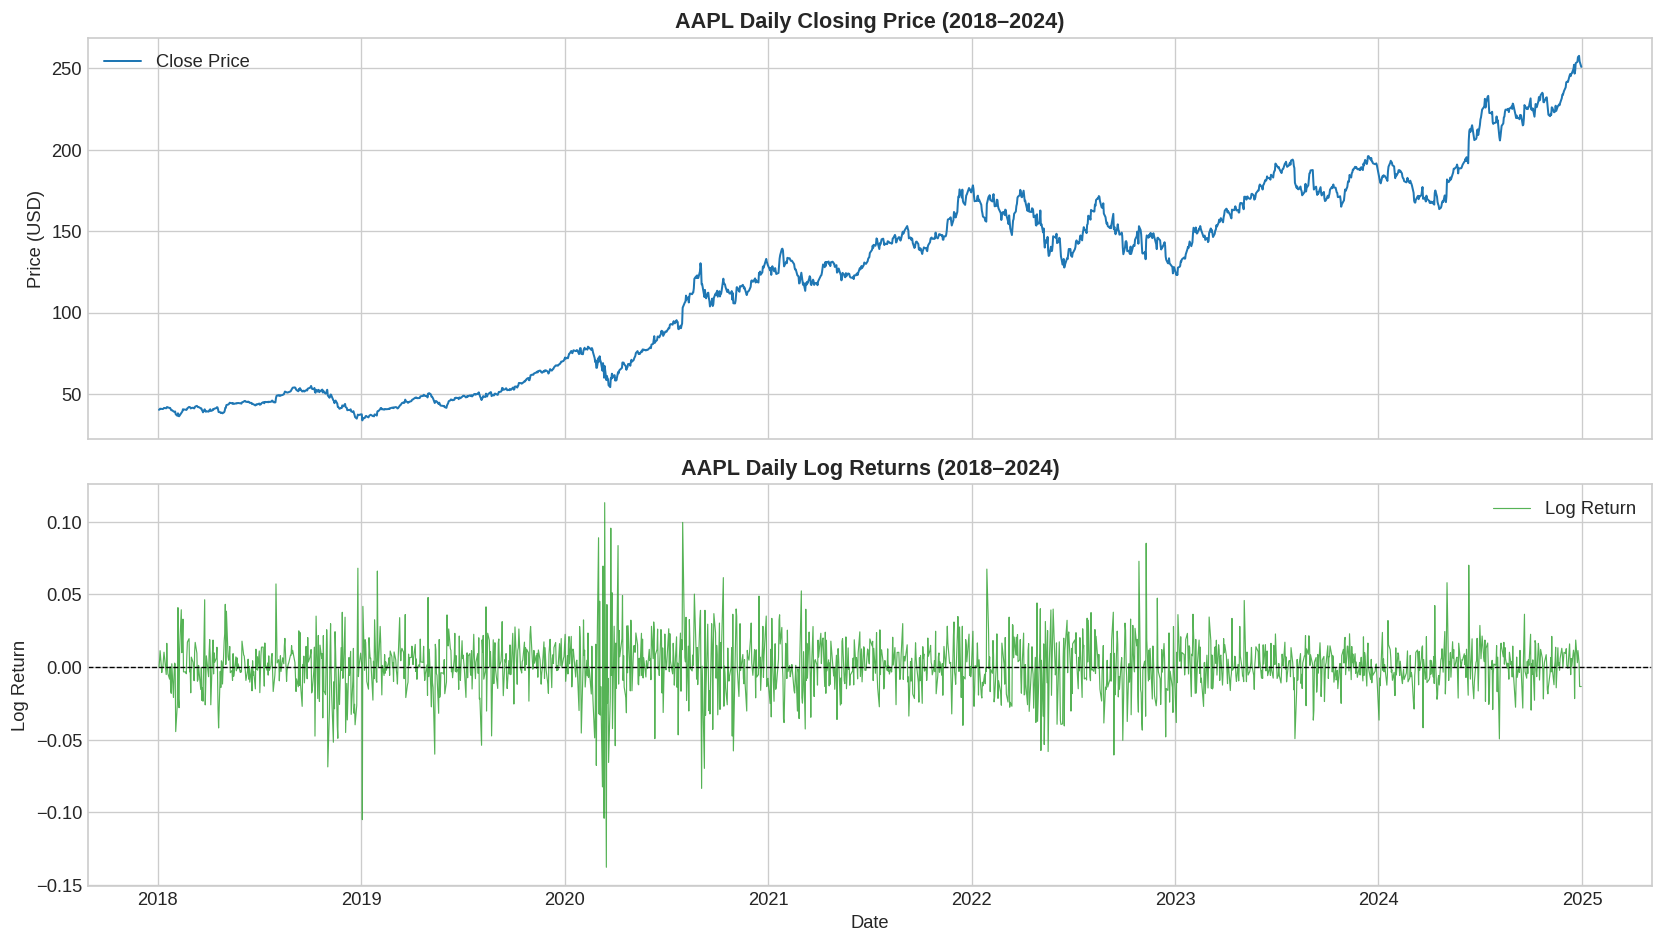

Figure 1: AAPL Closing Price and Log Returns


In [54]:
# Plot 1: AAPL Closing Price & Log Returns
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='#1f77b4', linewidth=1.2, label='Close Price')
axes[0].set_title('AAPL Daily Closing Price (2018–2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(df.index, df['Log_Return'], color='#2ca02c', linewidth=0.7, alpha=0.8, label='Log Return')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('AAPL Daily Log Returns (2018–2024)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot1_price_returns.png', bbox_inches='tight')
plt.show()
print('Figure 1: AAPL Closing Price and Log Returns')

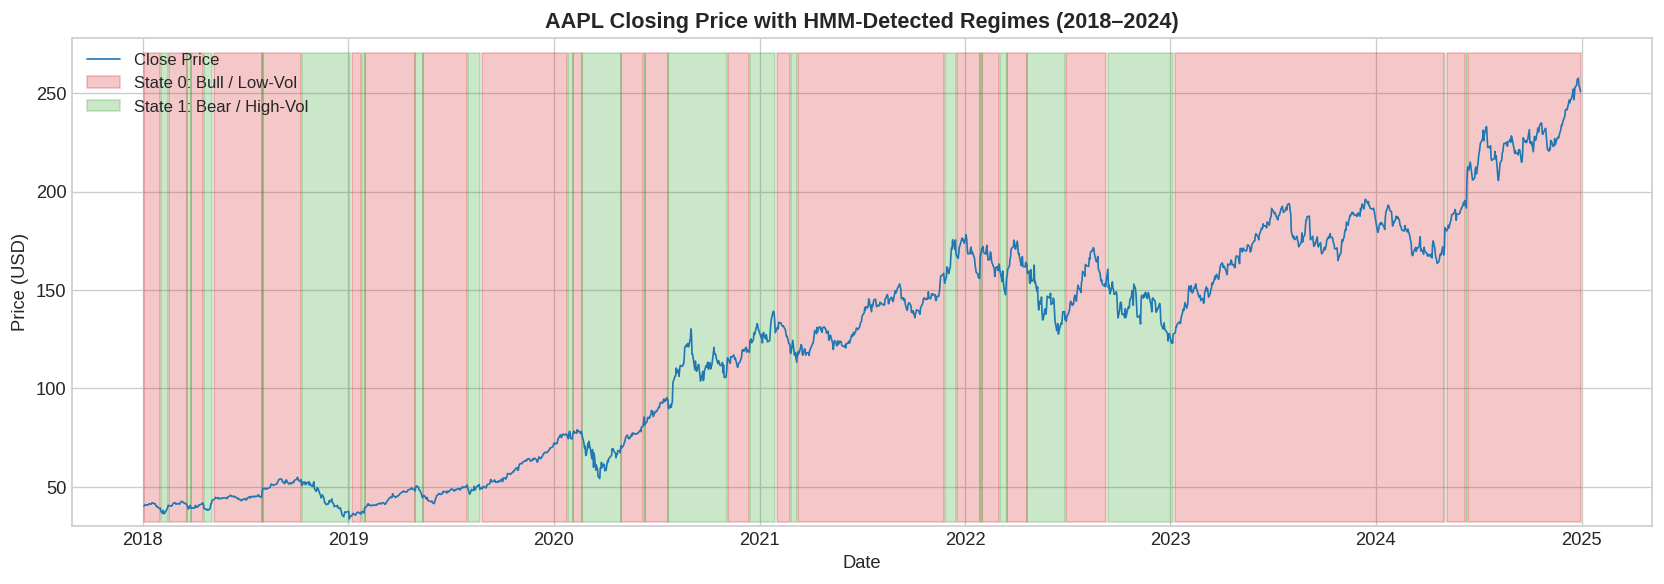

Figure 2: HMM Regime Overlay on AAPL Price


In [55]:
# Plot 2: HMM Regime Overlay on Price
colors_regime = {0: '#d62728', 1: '#2ca02c'}  # red=bear, green=bull
regime_label  = regime_labels  # defined in section 3.3

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.0, zorder=2, label='Close Price')

# Shade background by detected regime
for regime in [0, 1]:
    mask = df['Regime_HMM'] == regime
    ax.fill_between(
        df.index, df['Close'].min()*0.95, df['Close'].max()*1.05,
        where=mask, alpha=0.25,
        color=colors_regime[regime],
        label=f'State {regime}: {regime_label[regime]}'
    )

ax.set_title('AAPL Closing Price with HMM-Detected Regimes (2018–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(df['Close'].min()*0.90, df['Close'].max()*1.08)

plt.tight_layout()
plt.savefig('plot2_hmm_regimes.png', bbox_inches='tight')
plt.show()
print('Figure 2: HMM Regime Overlay on AAPL Price')

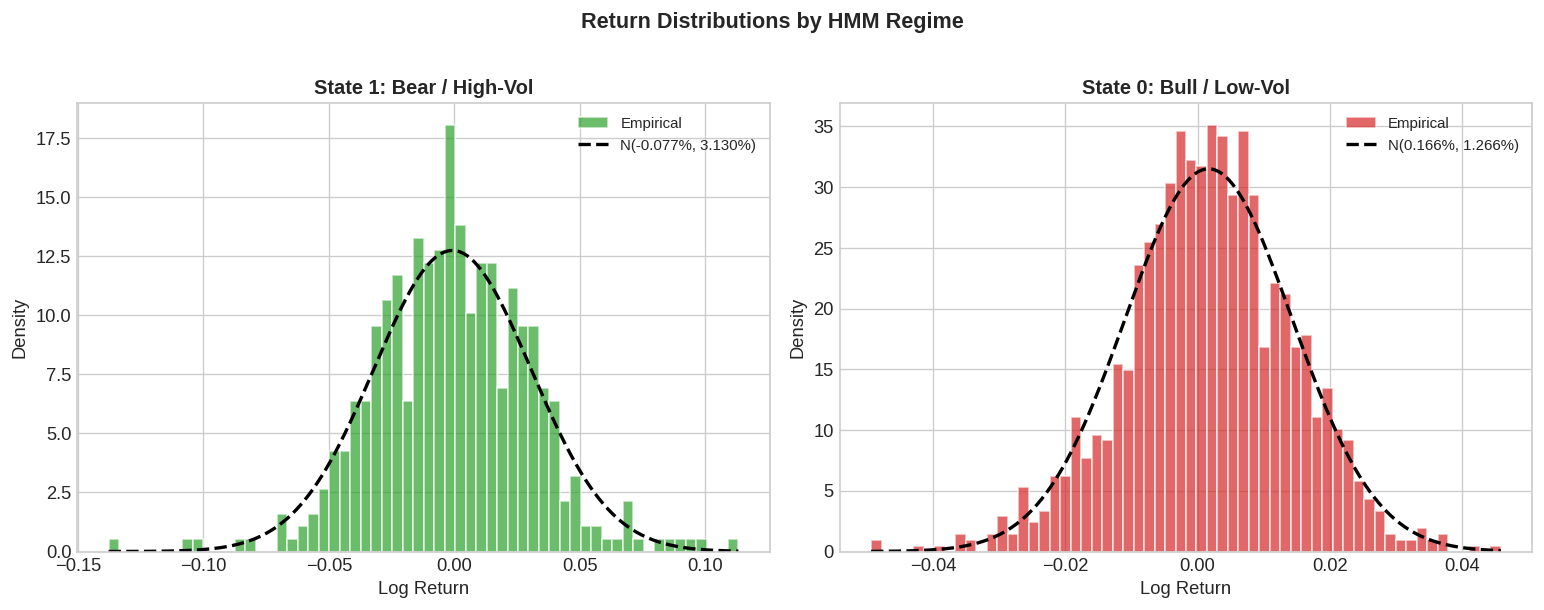

Figure 3: Return Distributions by Regime


In [56]:
# Plot 3: Return Distribution by Regime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (regime, label) in enumerate(regime_label.items()):
    data_r = df[df['Regime_HMM'] == regime]['Log_Return']
    axes[i].hist(data_r, bins=60, color=colors_regime[regime],
                 alpha=0.7, edgecolor='white', density=True, label='Empirical')

    # Overlay fitted normal
    x = np.linspace(data_r.min(), data_r.max(), 300)
    mu_fit, std_fit = data_r.mean(), data_r.std()
    axes[i].plot(x, stats.norm.pdf(x, mu_fit, std_fit),
                 'k--', linewidth=2, label=f'N({mu_fit*100:.3f}%, {std_fit*100:.3f}%)')

    axes[i].set_title(f'State {regime}: {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Log Return', fontsize=11)
    axes[i].set_ylabel('Density', fontsize=11)
    axes[i].legend(fontsize=9)

plt.suptitle('Return Distributions by HMM Regime', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot3_regime_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 3: Return Distributions by Regime')

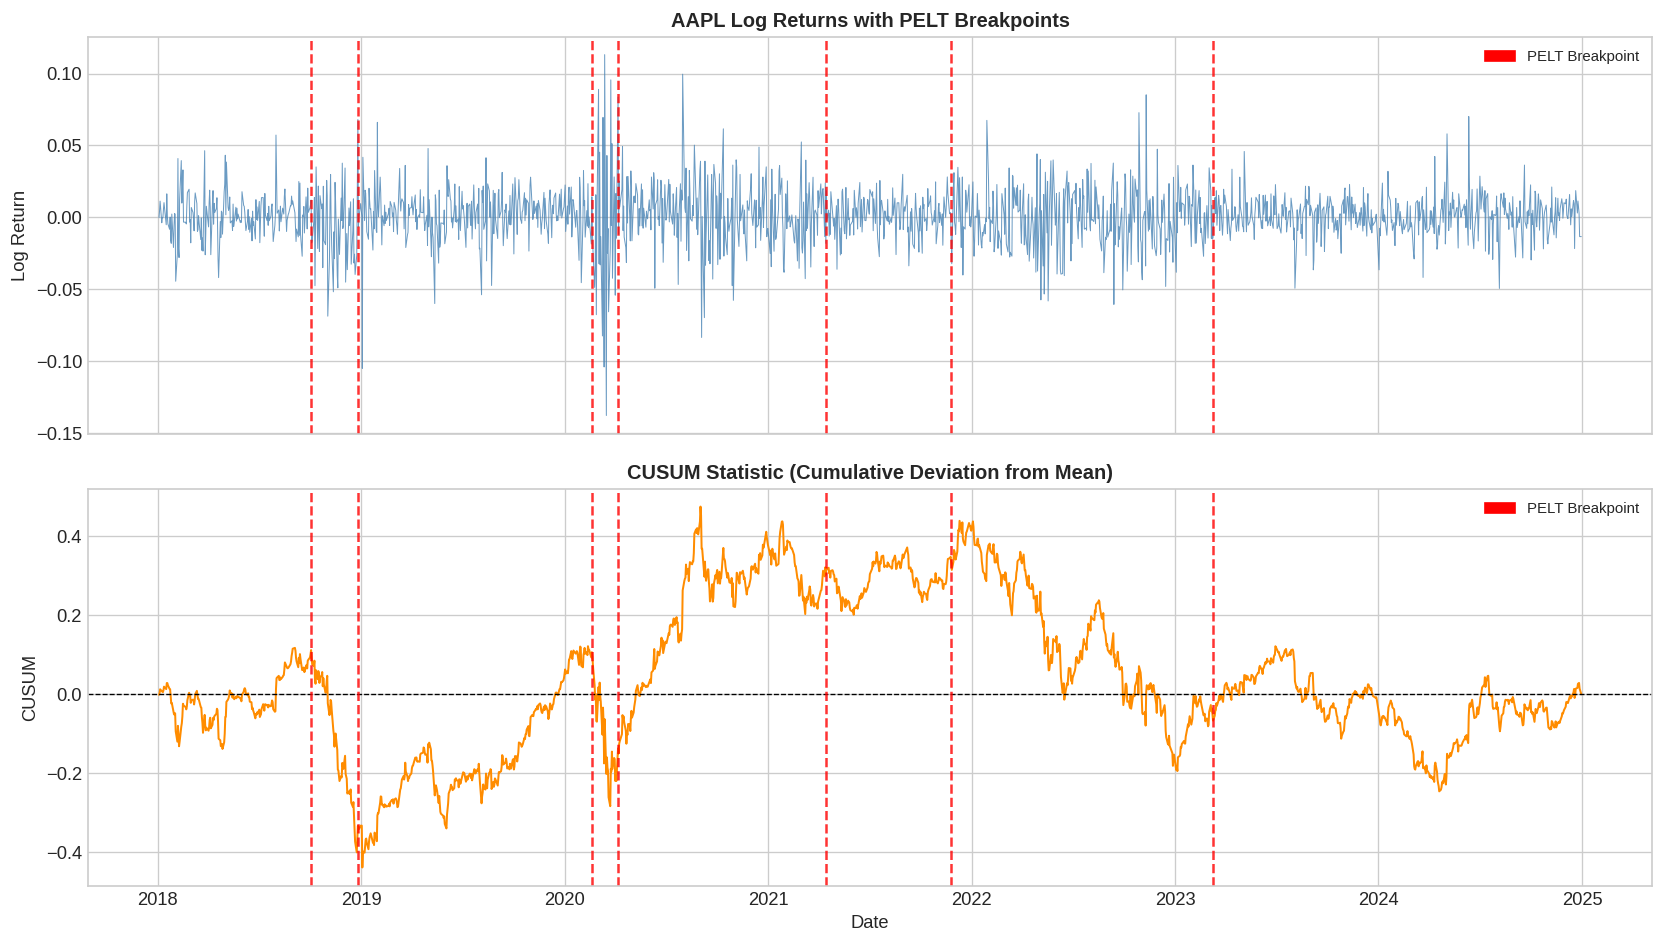

Figure 4: CUSUM Statistic and PELT Structural Breakpoints


In [57]:
# Plot 4: CUSUM Statistic & Structural Breakpoints
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Log_Return'], color='steelblue', linewidth=0.6, alpha=0.8)
for bp in bp_dates_pelt:
    axes[0].axvline(bp, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].set_title('AAPL Log Returns with PELT Breakpoints', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Return', fontsize=11)
red_line = mpatches.Patch(color='red', label='PELT Breakpoint')
axes[0].legend(handles=[red_line], fontsize=9)

axes[1].plot(df.index, df['CUSUM'], color='darkorange', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bp in bp_dates_pelt:
    axes[1].axvline(bp, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
axes[1].set_title('CUSUM Statistic (Cumulative Deviation from Mean)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('CUSUM', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(handles=[red_line], fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plot4_cusum.png', bbox_inches='tight')
plt.show()
print('Figure 4: CUSUM Statistic and PELT Structural Breakpoints')

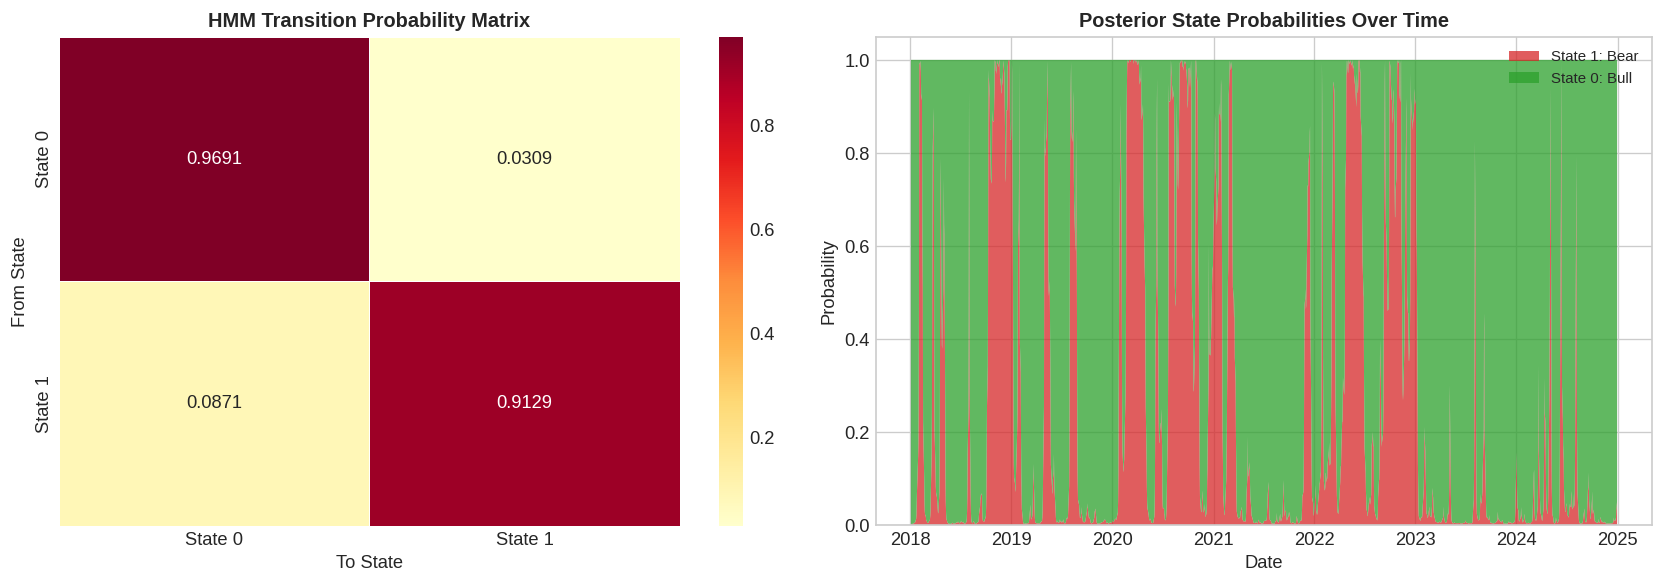

Figure 5: Transition Matrix and Posterior Probabilities


In [58]:
# Plot 5: Regime Transition Heatmap & Posterior Probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transition matrix heatmap
sns.heatmap(
    model_2.transmat_,
    annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=[f'State {i}' for i in range(2)],
    yticklabels=[f'State {i}' for i in range(2)],
    ax=axes[0], linewidths=0.5, linecolor='white'
)
axes[0].set_title('HMM Transition Probability Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('To State', fontsize=11)
axes[0].set_ylabel('From State', fontsize=11)

# Posterior state probabilities over time
posterior = model_2.predict_proba(returns)
axes[1].stackplot(
    df.index,
    posterior[:, sorted_idx[0]],  # bear regime
    posterior[:, sorted_idx[1]],  # bull regime
    labels=[f'State {sorted_idx[0]}: Bear', f'State {sorted_idx[1]}: Bull'],
    colors=['#d62728', '#2ca02c'],
    alpha=0.75
)
axes[1].set_title('Posterior State Probabilities Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Probability', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plot5_transition_posterior.png', bbox_inches='tight')
plt.show()
print('Figure 5: Transition Matrix and Posterior Probabilities')

---
## 5. Diagnosis
> *Diagnostic plots to assess model fit and residual behaviour*

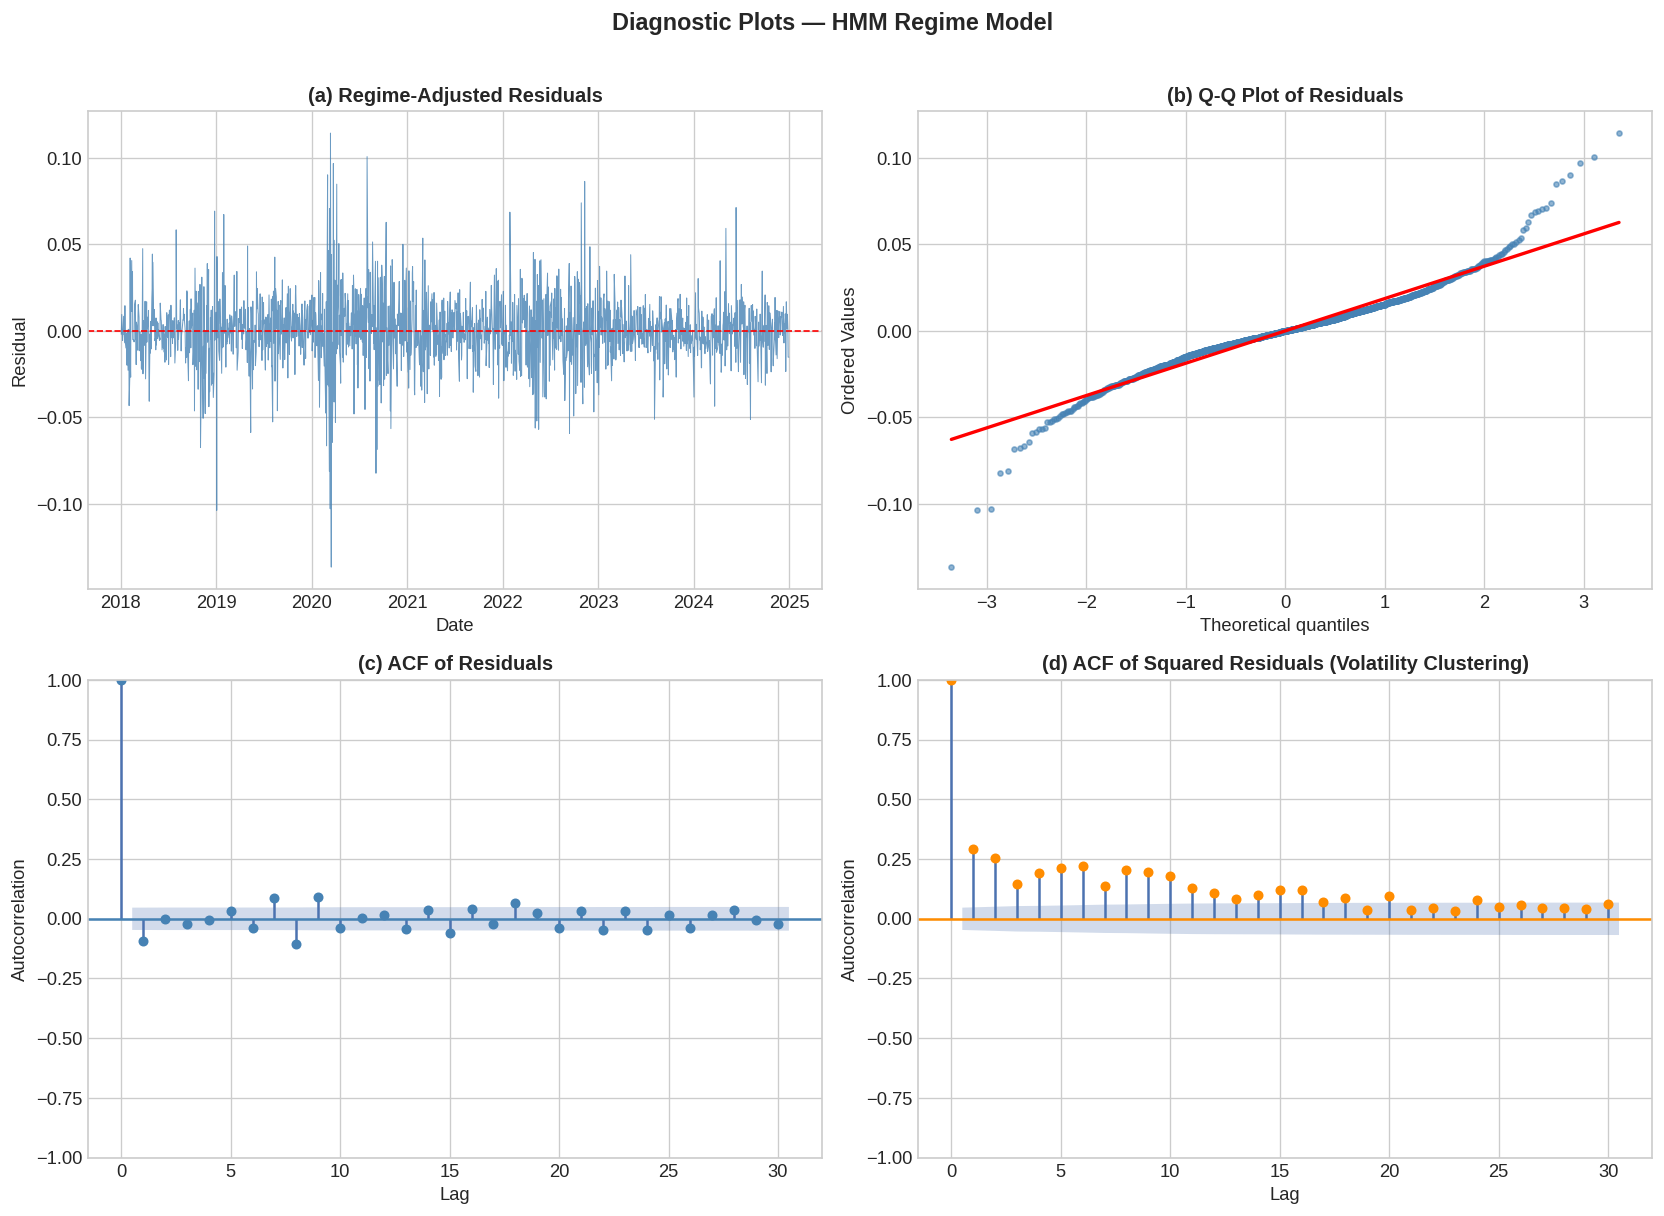

Figure 6: HMM Model Diagnostic Plots


In [59]:
# Compute regime-specific residuals
df['Residual'] = np.nan
for s in range(2):
    mask = df['Regime_HMM'] == s
    mu_s = model_2.means_[s, 0]
    df.loc[mask, 'Residual'] = df.loc[mask, 'Log_Return'] - mu_s

# Diagnostic Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Residuals over time
axes[0,0].plot(df.index, df['Residual'], color='steelblue', linewidth=0.6, alpha=0.8)
axes[0,0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('(a) Regime-Adjusted Residuals', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Residual')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (b) Q-Q plot
res_clean = df['Residual'].dropna()
stats.probplot(res_clean, dist='norm', plot=axes[0,1])
axes[0,1].set_title('(b) Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[0,1].get_lines()[0].set(color='steelblue', markersize=3, alpha=0.6)
axes[0,1].get_lines()[1].set(color='red', linewidth=2)

# (c) ACF of residuals
plot_acf(res_clean, lags=30, ax=axes[1,0], alpha=0.05, color='steelblue')
axes[1,0].set_title('(c) ACF of Residuals', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Lag'); axes[1,0].set_ylabel('Autocorrelation')

# (d) ACF of squared residuals (volatility clustering check)
plot_acf(res_clean**2, lags=30, ax=axes[1,1], alpha=0.05, color='darkorange')
axes[1,1].set_title('(d) ACF of Squared Residuals (Volatility Clustering)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Lag'); axes[1,1].set_ylabel('Autocorrelation')

plt.suptitle('Diagnostic Plots — HMM Regime Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot6_diagnostics.png', bbox_inches='tight')
plt.show()
print('Figure 6: HMM Model Diagnostic Plots')

In [60]:
# Ljung-Box test for residual autocorrelation
lb_result = acorr_ljungbox(res_clean, lags=[5, 10, 20], return_df=True)
print('Ljung-Box Test on Residuals')
print('(H₀: No autocorrelation up to lag k)')
print(lb_result.round(4))

# Normality test
stat_jb, p_jb = stats.jarque_bera(res_clean)
print(f'\nJarque-Bera Test: stat={stat_jb:.4f}, p={p_jb:.6f}')
if p_jb < 0.05:
    print('  → Residuals are NOT normally distributed (fat tails present).')
else:
    print('  → Residuals are approximately normally distributed.')

# Regime frequency summary
print('\nRegime Frequency Summary:')
regime_counts = df['Regime_HMM'].value_counts().sort_index()
for s, cnt in regime_counts.items():
    pct = cnt / len(df) * 100
    print(f'  State {s} ({regime_label[s]}): {cnt} days ({pct:.1f}%)')

Ljung-Box Test on Residuals
(H₀: No autocorrelation up to lag k)
    lb_stat  lb_pvalue
5   17.0833     0.0043
10  69.9439     0.0000
20  96.8686     0.0000

Jarque-Bera Test: stat=2031.9581, p=0.000000
  → Residuals are NOT normally distributed (fat tails present).

Regime Frequency Summary:
  State 0 (Bull / Low-Vol): 1309 days (74.4%)
  State 1 (Bear / High-Vol): 450 days (25.6%)


---
## 6. Damage
> *Problems revealed by the model and assessment of model quality challenges*

This section identifies model limitations and links them to the six challenges discussed in the group handbook.

**6.1 Fat Tails (Non-Normality)**  
The Jarque-Bera test above reveals significant excess kurtosis in the residuals. The Gaussian HMM assumes normally distributed emissions within each regime, but AAPL returns exhibit fat tails — particularly during COVID-19 crash days (March 2020). This understates tail risk in the Bear regime.

**6.2 Volatility Clustering Within Regimes**  
The ACF of squared residuals (Panel d above) shows significant autocorrelation at short lags, indicating that even after regime assignment, volatility clusters persist. A GARCH-augmented HMM would better capture this.

**6.3 Label Switching**  
HMM states are unordered — at different random seeds, "State 0" may flip from Bull to Bear. We mitigate this by sorting states by mean return, but the issue remains in multi-run comparisons.

**6.4 Regime Determination Sensitivity**  
The number of regimes K must be chosen a priori. Our AIC/BIC comparison guides this, but information criteria can disagree. With K=3, a "neutral" regime emerges that is plausible but harder to interpret.

**6.5 Look-Ahead Bias**  
Viterbi decoding (used here) uses the full sample to assign regime labels, introducing look-ahead bias. In real deployment, the filter probability (forward algorithm only) must be used.

**6.6 Non-Stationarity of Regimes Over Long Horizons**  
Over 6 years, the nature of "bear" markets evolves (flash crashes vs. prolonged downturns). A static 2-state HMM may conflate structurally different market environments into one state.

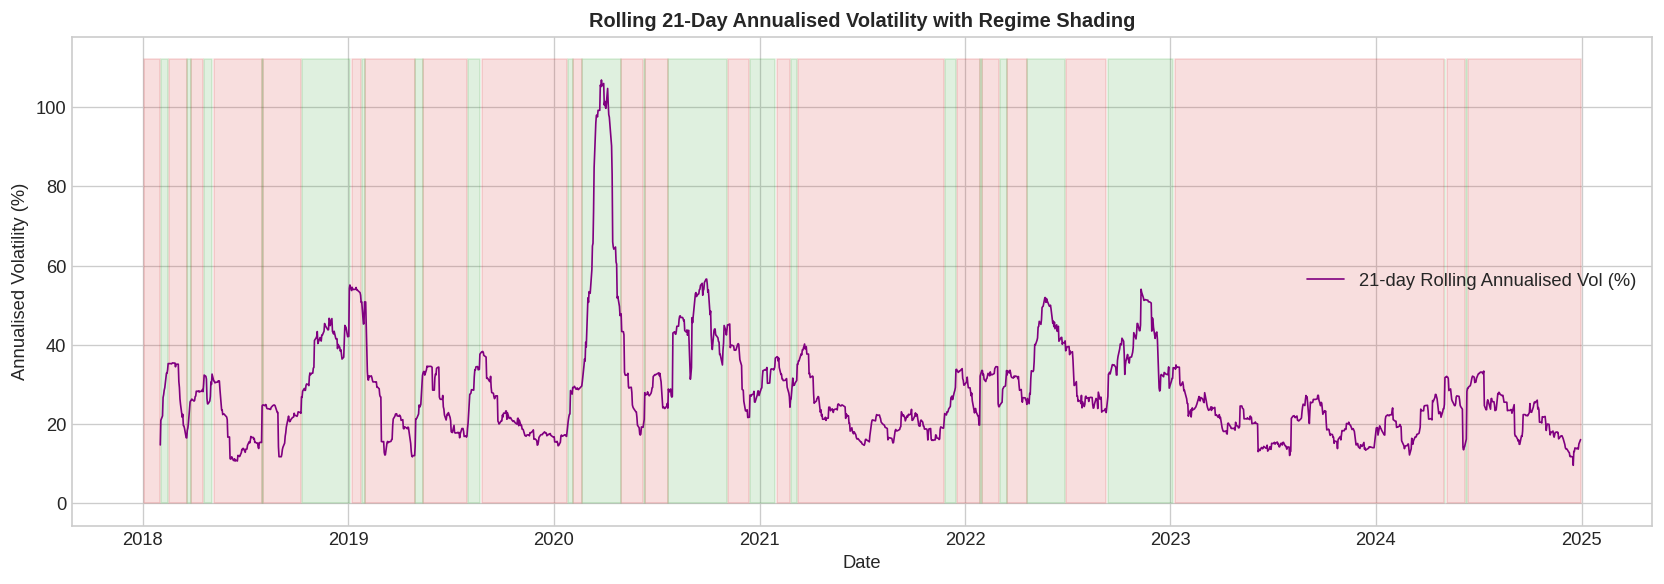

Figure 7: Rolling Volatility with HMM Regime Shading


In [61]:
# ── Rolling volatility to visualise volatility clustering ─────────────────────
df['RollingVol_21'] = df['Log_Return'].rolling(21).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['RollingVol_21'], color='purple', linewidth=1.0, label='21-day Rolling Annualised Vol (%)')
for s, clr in colors_regime.items():
    mask = df['Regime_HMM'] == s
    ax.fill_between(df.index, 0, df['RollingVol_21'].max()*1.05,
                    where=mask, alpha=0.15, color=clr)
ax.set_title('Rolling 21-Day Annualised Volatility with Regime Shading', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Annualised Volatility (%)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plot7_rolling_vol.png', bbox_inches='tight')
plt.show()
print('Figure 7: Rolling Volatility with HMM Regime Shading')

---
## 7. Directions
> *Data manipulations that should be considered if the model is to be refined:*

**7.1 Replace Gaussian Emissions with Student-t**  
Given the significant fat tails identified in Section 6, replacing the Gaussian emission distribution with a Student-t distribution would reduce the underestimation of extreme return probability. Libraries such as `pomegranate` support t-emission HMMs.

**7.2 Augment with GARCH Within Each Regime (RS-GARCH)**  
A Regime-Switching GARCH (RS-GARCH) model allows volatility to follow GARCH dynamics within each regime, resolving the volatility clustering problem identified in the diagnostics. This is available via the `arch` library.

**7.3 Shorten the Horizon Post-2020**  
The pre-COVID and post-COVID environments may be structurally different. Re-fitting the model on 2020–2024 only could yield cleaner, more homogeneous regimes.

**7.4 Remove Earnings Outliers**  
Extreme return days caused by quarterly earnings releases distort regime assignments. Flagging and downweighting these observations would improve regime stability.

**7.5 Use Real-Time (Filtered) Probabilities**  
Replace Viterbi decoding with real-time filtered probabilities to make the model deployable without look-ahead bias. This is available via `model.predict_proba()` run sequentially.

**7.6 Incorporate Exogenous Macro Features**  
Adding VIX (fear index) or Federal Funds Rate as input features to a Markov-Switching Regression model (via `statsmodels.tsa.regime_switching`) would allow regimes to be driven by observable macro conditions, improving interpretability.

In [62]:
# Subsample test: re-fit HMM on 2020–2024 only
df_sub = df.loc['2020-01-01':'2024-12-31'].copy()
returns_sub = df_sub['Log_Return'].values.reshape(-1, 1)

np.random.seed(42)
model_sub = GaussianHMM(n_components=2, covariance_type='full',
                        n_iter=1000, tol=1e-5, random_state=42)
model_sub.fit(returns_sub)
df_sub['Regime_Sub'] = model_sub.predict(returns_sub)

means_sub = model_sub.means_.flatten()
stds_sub  = np.sqrt(model_sub.covars_.flatten())
sorted_sub = np.argsort(means_sub)

print('Subsample Model (2020–2024) — Calibrated Parameters')
print('=' * 50)
for i in range(2):
    lbl = 'Bear / High-Vol' if i == sorted_sub[0] else 'Bull / Low-Vol'
    print(f'State {i} ({lbl}):')
    print(f'   Mean Daily Return: {means_sub[i]*100:.4f}%')
    print(f'   Daily Std Dev    : {stds_sub[i]*100:.4f}%')
    print()

print('Comparison: Full Sample vs Subsample Mean Returns')
for i in range(2):
    lbl_full = 'Bear' if i == sorted_idx[0] else 'Bull'
    print(f'  State {i} ({lbl_full}): Full={model_2.means_[i,0]*100:.4f}% | Sub={means_sub[i]*100:.4f}%')

Subsample Model (2020–2024) — Calibrated Parameters
State 0 (Bull / Low-Vol):
   Mean Daily Return: 0.1357%
   Daily Std Dev    : 1.4872%

State 1 (Bear / High-Vol):
   Mean Daily Return: -0.0733%
   Daily Std Dev    : 3.6929%

Comparison: Full Sample vs Subsample Mean Returns
  State 0 (Bull): Full=0.1820% | Sub=0.1357%
  State 1 (Bear): Full=-0.1167% | Sub=-0.0733%


---
## 8. Deployment
> *How would this model be used in practice?*

### 8.1 Real-Time Regime Signal

In production, the HMM would be retrained monthly on a rolling 2-year window of AAPL returns. Each trading day, the model computes the **filtered posterior probability** $P(S_t = \text{Bull} \mid r_1, \ldots, r_t)$ using only past observations (no look-ahead). This probability becomes the regime signal.

### 8.2 Portfolio Allocation Rule

A simple regime-conditional allocation strategy:

| Signal | Interpretation | Action |
|--------|---------------|--------|
| $P(\text{Bull} \mid \cdot) > 0.70$ | Confident Bull regime | Full equity allocation |
| $0.40 \leq P(\text{Bull} \mid \cdot) \leq 0.70$ | Uncertain / Transitioning | Reduce to 60% equity |
| $P(\text{Bull} \mid \cdot) < 0.40$ | Bear regime | Move 50%+ to cash / bonds |

### 8.3 Risk Management Integration
- **Value-at-Risk (VaR):** Compute regime-specific VaR using each state's $\mu_k$ and $\sigma_k$. A position-holder in AAPL would face a much larger 1-day 5% VaR in the Bear regime than in the Bull regime.
- **Stop-Loss Triggers:** A regime transition from Bull to Bear with posterior probability > 0.65 triggers an automatic position review.

### 8.4 Backtesting Limitation
Any deployment strategy must be backtested with forward-only (causal) regime probabilities. Using Viterbi-decoded states in a backtest introduces look-ahead bias and will inflate returns.

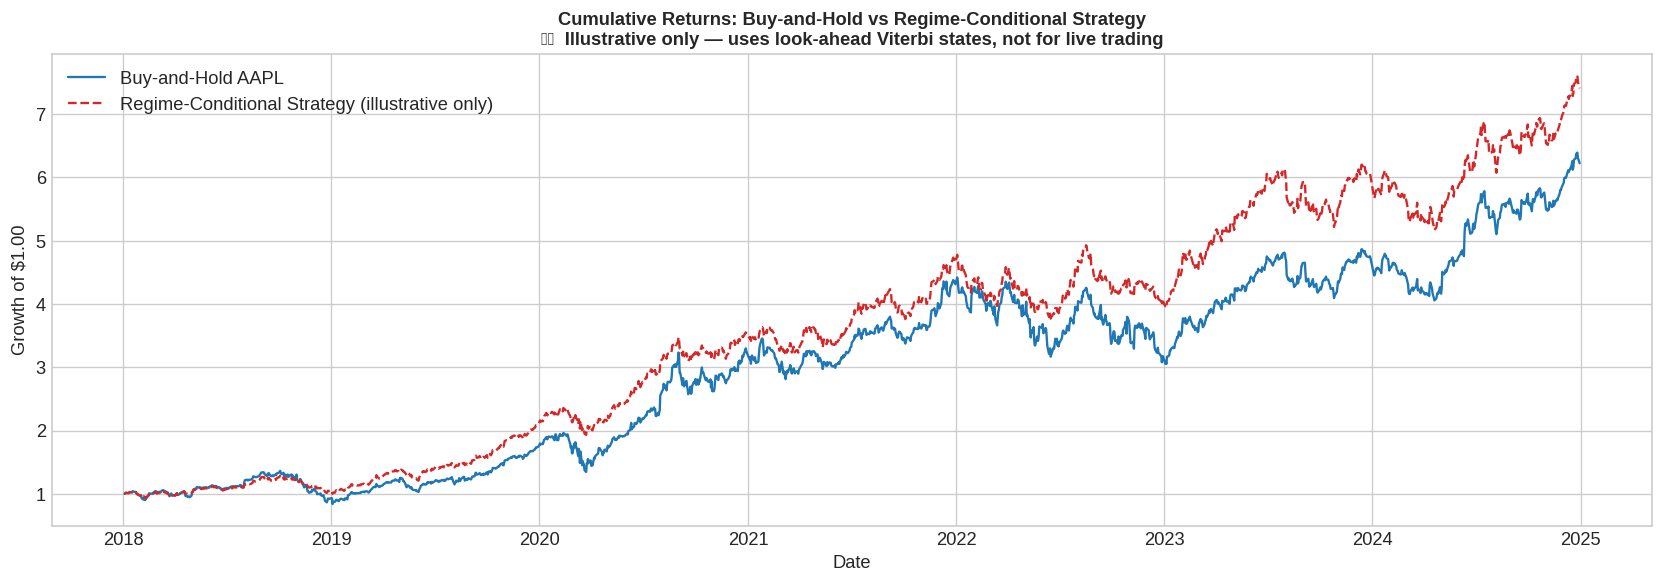

Buy-and-Hold cumulative return   : 522.3%
Regime strategy cumulative return: 640.7%

Note: Strategy reduces drawdown risk in Bear regimes at the cost of
some upside. In live deployment, filtered probabilities must be used.


In [63]:
# ── Simulated Deployment: Regime-Conditional Strategy vs Buy-and-Hold ─────────
# NOTE: This uses smoothed (Viterbi) states for illustration only.
# A real backtest must use filtered (forward-only) probabilities.

bull_state = sorted_idx[1]  # the higher-mean state

df['Strategy_Return'] = np.where(
    df['Regime_HMM'] == bull_state,
    df['Log_Return'],    # fully invested in Bull
    df['Log_Return'] * 0.5   # half invested in Bear
)

df['Cum_BuyHold']  = df['Log_Return'].cumsum().apply(np.exp)
df['Cum_Strategy'] = df['Strategy_Return'].cumsum().apply(np.exp)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Cum_BuyHold'],  color='#1f77b4', linewidth=1.4, label='Buy-and-Hold AAPL')
ax.plot(df.index, df['Cum_Strategy'], color='#d62728', linewidth=1.4, linestyle='--',
        label='Regime-Conditional Strategy (illustrative only)')
ax.set_title('Cumulative Returns: Buy-and-Hold vs Regime-Conditional Strategy\n'
             '⚠️  Illustrative only — uses look-ahead Viterbi states, not for live trading',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Growth of $1.00')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plot8_strategy.png', bbox_inches='tight')
plt.show()

bh_total  = df['Cum_BuyHold'].iloc[-1]
str_total = df['Cum_Strategy'].iloc[-1]
print(f'Buy-and-Hold cumulative return   : {(bh_total-1)*100:.1f}%')
print(f'Regime strategy cumulative return: {(str_total-1)*100:.1f}%')
print()
print('Note: Strategy reduces drawdown risk in Bear regimes at the cost of')
print('some upside. In live deployment, filtered probabilities must be used.')

---
## Bibliography (MLA Format)

Cappé, Olivier, Eric Moulines, and Tobias Rydén. *Inference in Hidden Markov Models*. Springer, 2005.

Hamilton, James D. "A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle." *Econometrica*, vol. 57, no. 2, 1989, pp. 357–384.

Killick, Rebecca, and Idris Eckley. "Changepoint: An R Package for Changepoint Analysis." *Journal of Statistical Software*, vol. 58, no. 3, 2014, pp. 1–19.

Rabiner, Lawrence R. "A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition." *Proceedings of the IEEE*, vol. 77, no. 2, 1989, pp. 257–286.

Yahoo Finance. "Apple Inc. (AAPL) Historical Data." *Yahoo Finance*, 2024, finance.yahoo.com/quote/AAPL/history/. Accessed 7 May 2026.

Zivot, Eric, and Donald W.K. Andrews. "Further Evidence on the Great Crash, the Oil-Price Shock, and the Unit-Root Hypothesis." *Journal of Business & Economic Statistics*, vol. 10, no. 3, 1992, pp. 251–270.